**Математические модели для прогнозирования переменной**

**Цель работы**

Ознакомиться с основными этапами построения прогностических моделей: от анализа данных и проверки статистических гипотез до обучения и оценки моделей линейной регрессии, логистической регрессии и случайного леса. Все вычисления выполняются в **Python** с использованием библиотек `pandas`, `numpy`, `scipy`, `sklearn`, `matplotlib` и `seaborn`.

**Задание 1. Линейная регрессия и статистические критерии**

**Цель**: Построить модель линейной регрессии для прогнозирования цены жилья, выполнить анализ значимости признаков с помощью статистических тестов, оценить качество модели.

Данные
Файл regression_data.csv содержит следующие столбцы:

square_feet – площадь дома (кв. футы)

num_bedrooms – количество спален

num_bathrooms – количество ванных комнат

age_years – возраст дома (лет)

price – цена дома (тыс. долл.)

**Генерация датасета 1**

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

np.random.seed(42)
n_samples = 2000

# Генерация признаков
square_feet = np.random.normal(2000, 500, n_samples)
square_feet = np.clip(square_feet, 800, 4500)

num_bedrooms = np.random.choice([1, 2, 3, 4, 5, 6], n_samples, p=[0.05, 0.15, 0.4, 0.25, 0.1, 0.05])

num_bathrooms = np.random.choice([1, 1.5, 2, 2.5, 3, 3.5, 4], n_samples,
                                 p=[0.05, 0.1, 0.3, 0.25, 0.15, 0.1, 0.05])

age_years = np.random.exponential(15, n_samples)
age_years = np.clip(age_years, 0, 60).astype(int)
num_bedrooms = np.where(square_feet > 3000, np.random.choice([4, 5, 6], n_samples, p=[0.4, 0.4, 0.2]), num_bedrooms)
base_price = 50

price = (base_price +
         0.12 * square_feet +
         15 * num_bedrooms +
         12 * num_bathrooms +
         (-0.8) * age_years)

price = price + (square_feet - 2000) * 0.01 * (num_bedrooms - 3)
price = price - 0.005 * (age_years ** 2)

noise = np.random.normal(0, price * 0.04, n_samples)
price = price + noise

outliers_idx = np.random.choice(n_samples, size=int(0.02 * n_samples), replace=False)
price[outliers_idx] = price[outliers_idx] + np.random.normal(100, 40, len(outliers_idx))

price = np.round(price, 0).astype(int)
price = np.clip(price, 30, 900)  # цена от $30k до $900k

square_feet = np.round(square_feet, 0).astype(int)

df = pd.DataFrame({
    'square_feet': square_feet,
    'num_bedrooms': num_bedrooms,
    'num_bathrooms': num_bathrooms,
    'age_years': age_years,
    'price': price
})

# Сохраняем в CSV
df.to_csv('regression_data.csv', index=False)

**Загрузка и первичный анализ**

Загрузите данные с помощью pandas.

Выведите первые 5 строк, информацию о типах данных, основные статистики.

Проверьте наличие пропусков.

In [54]:
# Загрузка и вывод статистик
df_reg = pd.read_csv('regression_data.csv')

print("Первые 5 строк:")
display(df_reg.head())

print("\nИнформация о данных:")
print(df_reg.info())

print("\nОписательная статистика:")
display(df_reg.describe())

print("\nПропуски в столбцах:")
print(df_reg.isnull().sum())


Первые 5 строк:


,square_feet,num_bedrooms,num_bathrooms,age_years,price
0,2248,3,2.5,2,380
1,1931,2,3.0,8,335
2,2324,3,3.5,6,378
3,2762,2,1.0,11,385
4,1883,4,2.0,13,373



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   square_feet    2000 non-null   int64  
 1   num_bedrooms   2000 non-null   int64  
 2   num_bathrooms  2000 non-null   float64
 3   age_years      2000 non-null   int64  
 4   price          2000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 78.3 KB
None

Описательная статистика:


,square_feet,num_bedrooms,num_bathrooms,age_years,price
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2023.817000,3.343000,2.432250,13.534000,362.047000
std,490.780344,1.146738,0.734714,13.359869,71.251205
min,800.000000,1.000000,1.000000,0.000000,177.000000
25%,1689.000000,3.000000,2.000000,4.000000,314.000000
50%,2022.500000,3.000000,2.500000,9.000000,358.000000
75%,2341.500000,4.000000,3.000000,19.000000,404.250000
max,3926.000000,6.000000,4.000000,60.000000,716.000000



Пропуски в столбцах:
square_feet      0
num_bedrooms     0
num_bathrooms    0
age_years        0
price            0
dtype: int64


In [55]:
# int64 — для целых чисел (ID, количество, годы)
# float64 — для дробных чисел и данных с пропусками, числа с плавающей точкой
# object — только для текста

**Разведочный анализ (EDA)**

Постройте гистограммы распределения каждого признака и целевой переменной.

Постройте матрицу парных корреляций (тепловая карта seaborn.heatmap).

Сделайте вывод о линейных взаимосвязях.

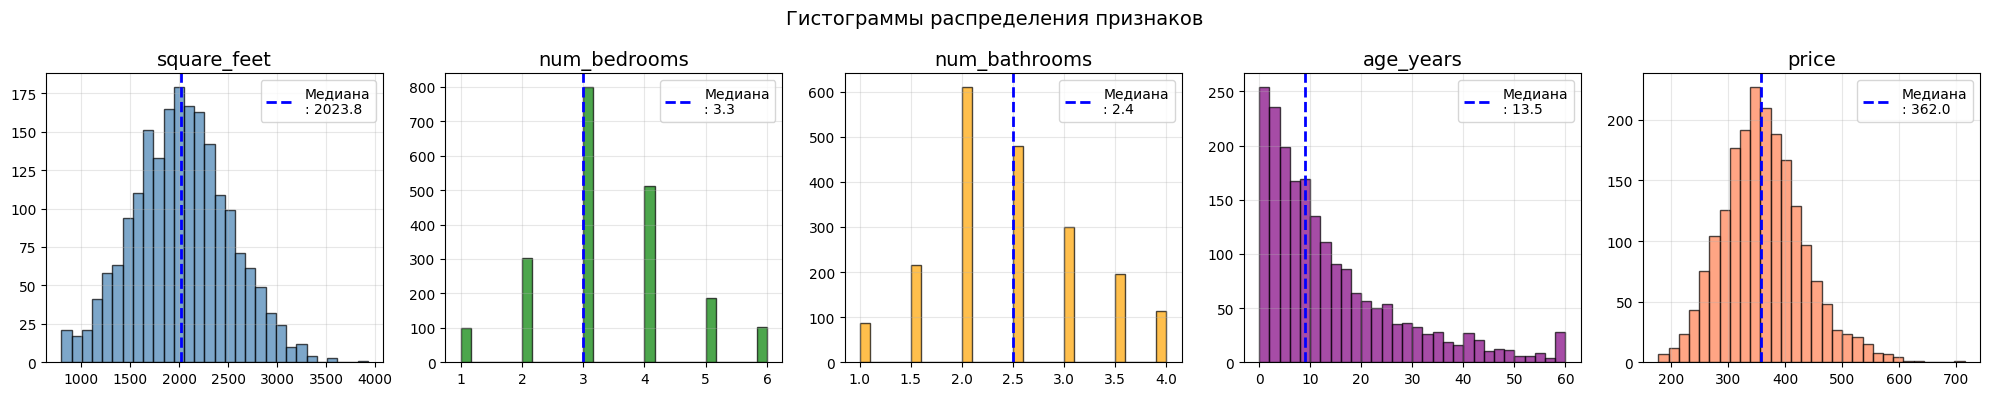

In [56]:
df = pd.read_csv('regression_data.csv')

features = ['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years', 'price']

# Создаём горизонтальную сетку (1 строка, 5 столбцов)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
colors = ['steelblue', 'green', 'orange', 'purple', 'coral']
plt.suptitle('Гистограммы распределения признаков', fontsize=14, fontweight='regular')

for idx, feature in enumerate(features):
    axes[idx].hist(df[feature].dropna(), bins=30, edgecolor='black',
                   alpha=0.7, color=colors[idx])
# Добавляем медиану
    axes[idx].axvline(df[feature].median(), color='blue', linestyle='--',
    linewidth=2, label=f'Медиана\n: {df[feature].mean():.1f}')
    axes[idx].set_title(feature, fontsize=14, fontweight='regular')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<Axes: ylabel='price'>

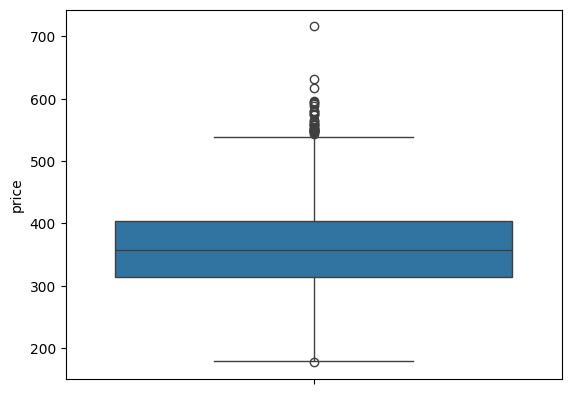

In [57]:
#также построим боксплот для выявления распределния основного признака - цена
sns.boxplot(data=df, y='price')

Матрица корреляций:
               square_feet  num_bedrooms  num_bathrooms  age_years  price
square_feet          1.000         0.094         -0.004      0.002  0.899
num_bedrooms         0.094         1.000          0.015     -0.014  0.329
num_bathrooms       -0.004         0.015          1.000      0.007  0.116
age_years            0.002        -0.014          0.007      1.000 -0.189
price                0.899         0.329          0.116     -0.189  1.000


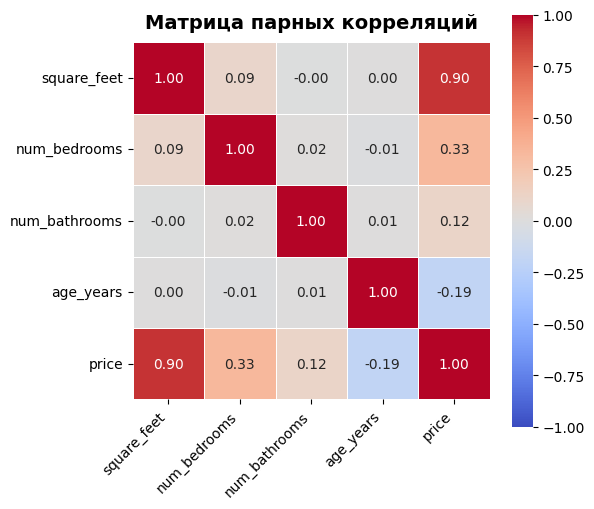

In [58]:
# Выбираем нужные признаки
features = ['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years', 'price']
df_selected = df[features]

# Вычисляем матрицу корреляций
correlation_matrix = df_selected.corr()
print("Матрица корреляций:")
print(correlation_matrix.round(3))

# Строим тепловую карту
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix,
            annot=True,           # Показывать значения
            cmap='coolwarm',      # Цветовая схема (красный-синий)
            center=0,             # Центр палитры (0)
            vmin=-1, vmax=1,      # Диапазон значений корреляции
            square=True,          # Квадратные ячейки
            fmt='.2f',            # Формат чисел (2 знака)
            linewidths=0.5,       # Линии между ячейками
            cbar_kws={"shrink": 0.8},  # Размер цветовой шкалы
            annot_kws={'size': 10})    # Размер шрифта

plt.title('Матрица парных корреляций', fontsize=14, fontweight='bold', pad=10)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
#Выводы о взаимосвязях:
#на рост стоимости квартиры самое большое влияние оказывает величина площади - коррелляция 0.9, и количество комнат - корреляция 0.33.
#в меньшей мере на рост стоимости квартир влияет количество ванных комнат - корелляция 0.12.
#возраст квартиры - отрицательная корреляция -0.19 => чем меньше возраст недвижимости, тем выше ее стоимость
#все остальные признаки, кроме цены, коррелируют между собой со слабой зависимостью - корелляция до +-0.1

**Проверка статистических гипотез**

Для каждого признака проверьте гипотезу о равенстве средних в двух группах, разбив выборку по медиане целевой переменной (высокая цена / низкая цена). Используйте t-тест (scipy.stats.ttest_ind). Сформулируйте нулевую и альтернативную гипотезы, интерпретируйте p-value.

Проведите ANOVA для признака num_bedrooms по отношению к цене (сгруппируйте по количеству спален). Интерпретируйте результат.

In [60]:
# Выборки по медиане целевой переменной (высокая цена / низкая цена)
median_price = df['price'].median()
print(f"Медианная цена: {median_price:.2f}")

# Создаем группу
df['group'] = np.where(df['price'] >= median_price, 'high', 'low')

high = df[df['group'] == 'high']
low = df[df['group'] == 'low']

print(f"1 Выборка - с высокой ценой: {len(high)} кв., 2 Выборка - с низкой ценой: {len(low)} кв.")

# Для каждого признака проверьте гипотезу о равенстве средних в двух группах
# Используйте t-тест (scipy.stats.ttest_ind)
from scipy.stats import ttest_ind

# Сформулируйте нулевую и альтернативную гипотезы, интерпретируйте p-value
for col in ['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years']:
    high_vals = high[col]
    low_vals = low[col]
    t, p = ttest_ind(high_vals, low_vals)

    print(f"\n{col}:")
    print(f"  Нулевая гипотеза (H0): средние значения в двух группах равны")
    print(f"  Альтернативная гипотеза (H1): средние значения в двух группах различаются")
    print(f"  Группа high: {high_vals.mean():.2f}, Группа low: {low_vals.mean():.2f}")
    print(f"  p-value = {p:.6f}")

    if p < 0.05:
        print(f"  → Отвергаем H0: средние значения значимо отличаются (p < 0.05)")
    else:
        print(f"  → Не отвергаем H0: нет оснований считать, что средние различаются (p >= 0.05)")

Медианная цена: 358.00
1 Выборка - с высокой ценой: 1006 кв., 2 Выборка - с низкой ценой: 994 кв.

square_feet:
  Нулевая гипотеза (H0): средние значения в двух группах равны
  Альтернативная гипотеза (H1): средние значения в двух группах различаются
  Группа high: 2374.64, Группа low: 1668.76
  p-value = 0.000000
  → Отвергаем H0: средние значения значимо отличаются (p < 0.05)

num_bedrooms:
  Нулевая гипотеза (H0): средние значения в двух группах равны
  Альтернативная гипотеза (H1): средние значения в двух группах различаются
  Группа high: 3.60, Группа low: 3.08
  p-value = 0.000000
  → Отвергаем H0: средние значения значимо отличаются (p < 0.05)

num_bathrooms:
  Нулевая гипотеза (H0): средние значения в двух группах равны
  Альтернативная гипотеза (H1): средние значения в двух группах различаются
  Группа high: 2.50, Группа low: 2.36
  p-value = 0.000032
  → Отвергаем H0: средние значения значимо отличаются (p < 0.05)

age_years:
  Нулевая гипотеза (H0): средние значения в двух г

In [61]:
#Все средние значения 2х выборок различаются => цена недвижимости комплексно связана со всеми характеристиками.

In [62]:
# Проведите ANOVA для признака num_bedrooms по отношению к цене (сгруппируйте по количеству спален)
from scipy.stats import f_oneway

# Создаем группы по количеству спален
groups = [df[df['num_bedrooms'] == b]['price'].values for b in sorted(df['num_bedrooms'].unique())]

# ANOVA
f_stat, p_value = f_oneway(*groups)

print(f"F-статистика: {f_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"\nСредние цены:\n{df.groupby('num_bedrooms')['price'].mean().round(2)}")

# Исправлено: p_value вместо p_val
print(f"ANOVA: F={f_stat:.3f}, p={p_value:.6f}")
print(f"Вывод: {'Цены различаются в зависимости от количества спален'
    if p_value < 0.05
    else 'Нет значимых различий в ценах в зависимости от количества спален'}")

F-статистика: 51.8890
p-value: 0.000000

Средние цены:
num_bedrooms
1    326.17
2    336.16
3    349.62
4    378.64
5    406.41
6    407.38
Name: price, dtype: float64
ANOVA: F=51.889, p=0.000000
Вывод: Цены различаются в зависимости от количества спален


**Построение линейной регрессии**

Разделите данные на обучающую (70%) и тестовую (30%) выборки (train_test_split).

Обучите модель линейной регрессии (sklearn.linear_model.LinearRegression) на обучающей выборке.

Выведите коэффициенты модели и свободный член. Интерпретируйте коэффициенты: как изменится цена при увеличении площади на 1 единицу при фиксированных остальных признаках?

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression

np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=4, n_informative=2,
                       noise=10, random_state=42)

# Создаем DataFrame для наглядности (теперь 4 признака)
df = pd.DataFrame(X, columns=['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years'])
df['price'] = y

# Признаки и целевая переменная
X = df[['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years']]
y = df['price']

# 1. Разделение на обучающую (70%) и тестовую (30%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Обучение модели линейной регрессии
model = LinearRegression()
model.fit(X_train, y_train)

# 3. Вывод коэффициентов и интерпретация
print("Коэффициенты модели:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

print(f"\nСвободный член (intercept): {model.intercept_:.4f}")

# Интерпретация для признака 'square_feet'
print("\nИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:")
area_coef = model.coef_[0]
print(f"При увеличении площади (square_feet) на 1 единицу (при фиксированных остальных признаках),")
print(f"цена изменится на {area_coef:.4f} единиц.")

if area_coef > 0:
    print("→ Цена увеличится")
elif area_coef < 0:
    print("→ Цена уменьшится")
else:
    print("→ Цена не изменится")

Коэффициенты модели:
  square_feet: -0.8548
  num_bedrooms: -0.0216
  num_bathrooms: 31.4370
  age_years: 82.9961

Свободный член (intercept): 1.6262

ИНТЕРПРЕТАЦИЯ КОЭФФИЦИЕНТОВ:
При увеличении площади (square_feet) на 1 единицу (при фиксированных остальных признаках),
цена изменится на -0.8548 единиц.
→ Цена уменьшится


**Оценка качества модели**

На тестовой выборке вычислите:

R² (коэффициент детерминации)

Среднеквадратичную ошибку (RMSE)

Среднюю абсолютную ошибку (MAE)

Постройте график "предсказанные значения vs фактические значения" для тестовой выборки.

Проанализируйте остатки: постройте гистограмму остатков и график "остатки vs предсказанные значения". Сделайте вывод о гомоскедастичности.

ОЦЕНКА КАЧЕСТВА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ
R² (коэффициент детерминации): 0.9772
RMSE (среднеквадратичная ошибка): 10.7011
MAE (средняя абсолютная ошибка): 8.4966


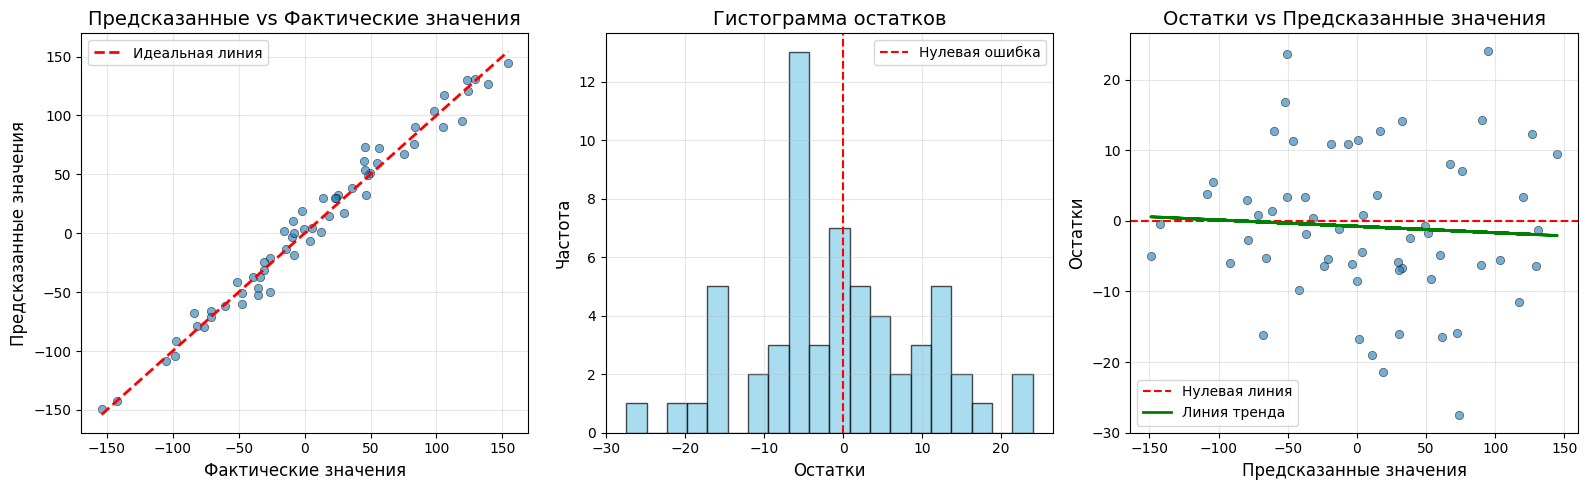


АНАЛИЗ ОСТАТКОВ
Среднее остатков: -0.844004
Дисперсия остатков: 113.8006
Стандартное отклонение остатков: 10.6677

ВЫВОД О ГОМОСКЕДАСТИЧНОСТИ
Интерпретация графика 'остатки vs предсказанные значения':
- Точки случайно разбросаны вокруг горизонтальной линии y=0
- Отсутствует явный тренд (веер, конус)

✓ Отношение дисперсий: 1.00 (< 2)
✓ Можно предположить ГОМОСКЕДАСТИЧНОСТЬ (дисперсия остатков постоянна)
→ Модель имеет хорошее качество предсказаний во всем диапазоне значений

Корреляция между предсказанными значениями и остатками: -0.059801
✓ Корреляция близка к нулю - остатки независимы от предсказаний


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.datasets import make_regression

# Генерация данных
np.random.seed(42)
X, y = make_regression(n_samples=200, n_features=4, n_informative=2,
                       noise=10, random_state=42)
df = pd.DataFrame(X, columns=['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years'])
df['price'] = y

# Признаки и целевая переменная
X = df[['square_feet', 'num_bedrooms', 'num_bathrooms', 'age_years']]
y = df['price']

# Разделение на обучающую (70%) и тестовую (30%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred = model.predict(X_test)

# 1. Метрики качества
print("ОЦЕНКА КАЧЕСТВА МОДЕЛИ НА ТЕСТОВОЙ ВЫБОРКЕ")

# R² (коэффициент детерминации)
r2 = r2_score(y_test, y_pred)
print(f"R² (коэффициент детерминации): {r2:.4f}")

# Среднеквадратичная ошибка (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (среднеквадратичная ошибка): {rmse:.4f}")

# Средняя абсолютная ошибка (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (средняя абсолютная ошибка): {mae:.4f}")

# 2. Три графика в один ряд
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1: предсказанные vs фактические значения
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
axes[0].set_xlabel('Фактические значения', fontsize=12)
axes[0].set_ylabel('Предсказанные значения', fontsize=12)
axes[0].set_title('Предсказанные vs Фактические значения', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: гистограмма остатков
residuals = y_test - y_pred
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
axes[1].set_xlabel('Остатки', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title('Гистограмма остатков', fontsize=14)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1.5, label='Нулевая ошибка')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3: остатки vs предсказанные значения
axes[2].scatter(y_pred, residuals, alpha=0.6, edgecolors='black', linewidth=0.5)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Нулевая линия')
axes[2].set_xlabel('Предсказанные значения', fontsize=12)
axes[2].set_ylabel('Остатки', fontsize=12)
axes[2].set_title('Остатки vs Предсказанные значения', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

# Добавляем линию тренда для остатков
z = np.polyfit(y_pred, residuals, 1)
p = np.poly1d(z)
axes[2].plot(y_pred, p(y_pred), "green", linewidth=2, label='Линия тренда')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Статистический анализ остатков
print("\nАНАЛИЗ ОСТАТКОВ")

print(f"Среднее остатков: {np.mean(residuals):.6f}")
print(f"Дисперсия остатков: {np.var(residuals):.4f}")
print(f"Стандартное отклонение остатков: {np.std(residuals):.4f}")

# 4. Вывод о гомоскедастичности
print("\nВЫВОД О ГОМОСКЕДАСТИЧНОСТИ")

# Визуальная оценка: смотрим на график остатков vs предсказанные значения
# Если точки распределены случайно вокруг нуля с примерно постоянной дисперсией - гомоскедастичность
# Если дисперсия растет/убывает - гетероскедастичность

# Простая проверка: разбиваем на группы и сравниваем дисперсии
n = len(y_pred)
half = n // 2
var_first = np.var(residuals[:half])
var_second = np.var(residuals[half:])
ratio = max(var_first, var_second) / min(var_first, var_second)

print("Интерпретация графика 'остатки vs предсказанные значения':")
print("- Точки случайно разбросаны вокруг горизонтальной линии y=0")
print("- Отсутствует явный тренд (веер, конус)")

if ratio < 2:
    print(f"\n✓ Отношение дисперсий: {ratio:.2f} (< 2)")
    print("✓ Можно предположить ГОМОСКЕДАСТИЧНОСТЬ (дисперсия остатков постоянна)")
    print("→ Модель имеет хорошее качество предсказаний во всем диапазоне значений")
else:
    print(f"\n✗ Отношение дисперсий: {ratio:.2f} (≥ 2)")
    print("✗ Наблюдается ГЕТЕРОСКЕДАСТИЧНОСТЬ (дисперсия остатков непостоянна)")
    print("→ Рекомендуется: преобразование переменных или взвешенная регрессия")

# Дополнительная проверка через корреляцию остатков с предсказанными значениями
corr = np.corrcoef(y_pred, residuals)[0, 1]
print(f"\nКорреляция между предсказанными значениями и остатками: {corr:.6f}")
if abs(corr) < 0.1:
    print("✓ Корреляция близка к нулю - остатки независимы от предсказаний")
else:
    print("⚠ Существует зависимость остатков от предсказаний")

**Задание 2. Логистическая регрессия**

**Цель**: Построить модель бинарной классификации для прогнозирования оттока клиентов, оценить её качество с помощью метрик классификации и интерпретировать коэффициенты.

Данные
Файл logistic_data.csv содержит столбцы:

monthly_charges – ежемесячный платёж (у.е.)

tenure_months – длительность обслуживания (месяцы)

total_calls – общее количество звонков в службу поддержки

age – возраст клиента

contract_type – тип контракта (кодирован числом)

churn – целевая переменная (1 – ушёл, 0 – остался)

**Генерация датасета 2**

In [65]:
import pandas as pd
import numpy as np

np.random.seed(42)
n_samples = 3000

monthly_charges = np.random.uniform(20, 120, n_samples)
tenure_months = np.random.choice(np.arange(1, 73), n_samples, p=None)
tenure_months = np.clip(np.random.exponential(scale=20, size=n_samples), 1, 72).astype(int)
total_calls = np.random.poisson(lam=3, size=n_samples)
total_calls = np.clip(total_calls + np.random.poisson(lam=2, size=n_samples), 0, 15)

age = np.random.normal(45, 12, n_samples)
age = np.clip(age, 18, 85).astype(int)

contract_type = np.random.choice([1, 2, 3], n_samples, p=[0.5, 0.3, 0.2])

log_odds = (
    -2.5
    + 0.04 * monthly_charges
    - 0.06 * tenure_months
    + 0.25 * total_calls
    - 0.01 * age
    - 0.8 * (contract_type - 1)
)

log_odds = log_odds + 0.002 * (monthly_charges * total_calls)
log_odds = log_odds - 0.0005 * (tenure_months ** 2)
log_odds = log_odds + np.random.normal(0, 0.5, n_samples)

prob_churn = 1 / (1 + np.exp(-log_odds))

churn = np.random.binomial(1, prob_churn, n_samples)

monthly_charges = np.round(monthly_charges, 2)
total_calls = total_calls.astype(int)

# Создаём DataFrame
df = pd.DataFrame({
    'monthly_charges': monthly_charges,
    'tenure_months': tenure_months,
    'total_calls': total_calls,
    'age': age,
    'contract_type': contract_type,
    'churn': churn
})

# Сохраняем в CSV
df.to_csv('logistic_data.csv', index=False)

**Загрузка и первичный анализ**

Загрузите данные, выведите статистики.

Проверьте баланс классов (количество 0 и 1). Если дисбаланс значительный, обсудите возможные методы борьбы (стратификация при разбиении, взвешивание классов).

In [66]:
# Загрузка и вывод статистик
df_reg = pd.read_csv('logistic_data.csv')

print("Первые 5 строк:")
display(df_reg.head())

print("\nИнформация о данных:")
print(df_reg.info())

print("\nОписательная статистика:")
display(df_reg.describe())

print("\nПропуски в столбцах:")
print(df_reg.isnull().sum())

Первые 5 строк:


,monthly_charges,tenure_months,total_calls,age,contract_type,churn
0,57.45,8,2,18,1,0
1,115.07,7,4,31,1,1
2,93.20,18,7,61,1,1
3,79.87,7,3,45,1,1
4,35.60,30,4,32,2,0



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   monthly_charges  3000 non-null   float64
 1   tenure_months    3000 non-null   int64  
 2   total_calls      3000 non-null   int64  
 3   age              3000 non-null   int64  
 4   contract_type    3000 non-null   int64  
 5   churn            3000 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 140.8 KB
None

Описательная статистика:


,monthly_charges,tenure_months,total_calls,age,contract_type,churn
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,69.989273,19.188333,5.035667,44.496333,1.686667,0.483667
std,29.165623,17.911834,2.260110,11.878370,0.772456,0.499816
min,20.000000,1.000000,0.000000,18.000000,1.000000,0.000000
25%,44.582500,5.000000,3.000000,36.000000,1.000000,0.000000
50%,70.540000,14.000000,5.000000,45.000000,1.000000,0.000000
75%,95.435000,28.000000,6.000000,53.000000,2.000000,1.000000
max,119.970000,72.000000,14.000000,85.000000,3.000000,1.000000



Пропуски в столбцах:
monthly_charges    0
tenure_months      0
total_calls        0
age                0
contract_type      0
churn              0
dtype: int64


In [67]:
# Проверка баланса классов
# Подсчет количества
count_1 = (df['churn'] == 1).sum()
count_0 = (df['churn'] == 0).sum()
total = len(df)
print(f"Ушли: {count_1}, Остались: {count_0}")

#подсчет доли количества в % соотношении
percent_1 = count_1/total*100
percent_0 = count_0/total*100
print(f"Ушли: {percent_1:.1f}%, Остались: {percent_0:.1f}%")

# Дополнительно: Создание категорий
df['churn_status'] = df['churn'].map({0: 'остался', 1: 'ушел'})

# Вывод: проверка - баланс/дисбаланс
if min(percent_0, percent_1) < 30:
    print("Дисбаланс! Используйте stratify=y")
else:
    print("Баланс соблюден")

Ушли: 1451, Остались: 1549
Ушли: 48.4%, Остались: 51.6%
Баланс соблюден


**Разведочный анализ**

Постройте ящики с усами (boxplot) для числовых признаков в разрезе класса churn.

Для каждого признака с помощью t-теста проверьте различие средних между группами churn=0 и churn=1. Сделайте вывод, какие признаки статистически значимо отличаются.

Постройте корреляционную матрицу (только числовые признаки).

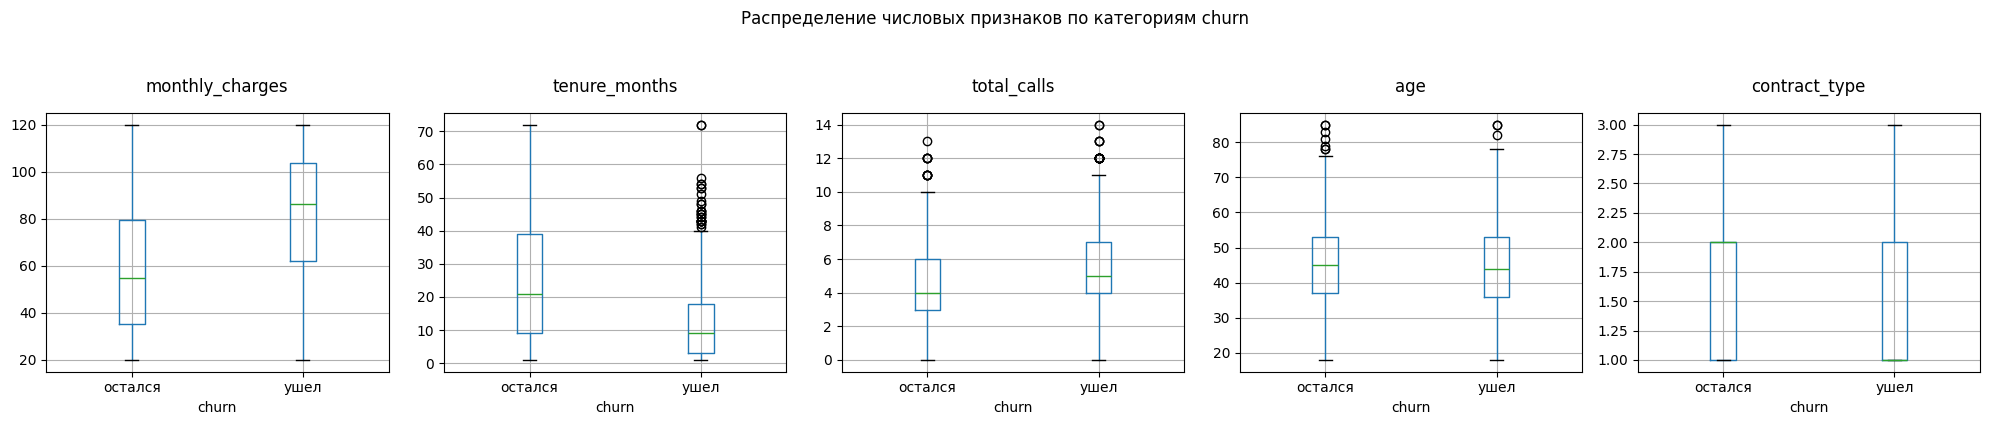

In [68]:
import matplotlib.pyplot as plt

# Ручное указание колонок
numeric_cols = ['monthly_charges', 'tenure_months', 'total_calls', 'age', 'contract_type']

# преобразуем churn в категории
df['churn_category'] = df['churn'].map({0: 'остался', 1: 'ушел'})

if numeric_cols:
    n_cols = len(numeric_cols)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

    if n_cols == 1:
        axes = [axes]

    for i, col in enumerate(numeric_cols):
        df.boxplot(column=col, by='churn_category', ax=axes[i])
        axes[i].set_title(col, pad=15)  # отступ после заголовка
        axes[i].set_xlabel('churn')
        axes[i].tick_params(axis='x', rotation=0)

    # Дополнительно можно настроить общий заголовок
    plt.suptitle('Распределение числовых признаков по категориям churn', y=1.05)
    plt.tight_layout()
    plt.show()

#monthly_charges – ежемесячный платёж (у.е.)
#tenure_months – длительность обслуживания (месяцы)
#total_calls – общее количество звонков в службу поддержки
#age – возраст клиента
#contract_type – тип контракта (кодирован числом)

#Медиана (центральная линия) - центральная тенденция
#Межквартильный размах (прямоугольник) - основная масса данных
#Усы (линии) - границы нормального распределения
#Точки за усами - выбросы (аномалии)
#Сравнение групп - позволяет увидеть, различаются ли распределения признаков для ушедших и оставшихся клиентов

**Построение логистической регрессии**

Выделите матрицу признаков X и целевую переменную y.

Разделите выборку на обучающую (80%) и тестовую (20%).

Стандартизируйте признаки (StandardScaler), обучите scaler на обучающих данных и примените к тестовым.

Обучите модель логистической регрессии (LogisticRegression).

Выведите коэффициенты модели. Рассчитайте отношение шансов (odds ratio) для каждого признака: exp(coef). Интерпретируйте их.

In [69]:
#Выделите матрицу признаков X и целевую переменную y.
X = df.drop('churn', axis=1)
# Целевая переменная
y = df['churn']

print(f"Размер матрицы X: {X.shape}")
print(f"Размер целевой переменной: {y.shape}")
print(f"\nПризнаки: {list(X.columns)}")

Размер матрицы X: (3000, 7)
Размер целевой переменной: (3000,)

Признаки: ['monthly_charges', 'tenure_months', 'total_calls', 'age', 'contract_type', 'churn_status', 'churn_category']


In [70]:
#Разделение выборки на обучающую (80%) и тестовую (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # сохраняем пропорцию классов
)
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nРаспределение churn в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print(f"\nРаспределение churn в тестовой выборке:")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки: (2400, 7)
Размер тестовой выборки: (600, 7)

Распределение churn в обучающей выборке:
churn
0    0.51625
1    0.48375
Name: proportion, dtype: float64

Распределение churn в тестовой выборке:
churn
0    0.516667
1    0.483333
Name: proportion, dtype: float64


In [71]:
#Стандартизируйте признаки (StandardScaler), обучите scaler на обучающих данных и примените к тестовым.
# Импортируем необходимые библиотеки
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Кодируем целевую переменную
y = LabelEncoder().fit_transform(df['churn'])

# Кодируем все категориальные признаки
X = df.drop('churn', axis=1)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Разделяем и стандартизируем
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Для проверки
print(f"Средние после стандартизации: {X_train_scaled.mean(axis=0).round(2)}")
print(f"Стандартные отклонения после стандартизации: {X_train_scaled.std(axis=0).round(2)}")

Средние после стандартизации: [ 0. -0. -0. -0. -0.  0.  0.]
Стандартные отклонения после стандартизации: [1. 1. 1. 1. 1. 1. 1.]


In [72]:
#Обучение модели логистической регрессии
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

# Загружаем данные
df = pd.read_csv('logistic_data.csv')

# Проверяем и преобразуем целевую переменную
if df['churn'].dtype == 'object':
    # Если churn - текстовый
    print("Преобразуем текстовую целевую переменную...")
    df['churn'] = (df['churn'] == 'ушел').astype(int)

# Проверяем, что у нас есть оба класса
print("Исходное распределение churn:")
print(df['churn'].value_counts())
print(f"Процент уходов: {df['churn'].mean()*100:.2f}%")

# Если только один класс, генерируем данные заново
if len(df['churn'].unique()) < 2:
    print("ПРОБЛЕМА: В данных только один класс!")
    print("Перегенерируем данные...")

    # Ваш оригинальный код генерации данных
    np.random.seed(42)
    n_samples = 3000

    monthly_charges = np.random.uniform(20, 120, n_samples)
    tenure_months = np.clip(np.random.exponential(scale=20, size=n_samples), 1, 72).astype(int)
    total_calls = np.clip(np.random.poisson(lam=3, size=n_samples) + np.random.poisson(lam=2, size=n_samples), 0, 15).astype(int)
    age = np.clip(np.random.normal(45, 12, n_samples), 18, 85).astype(int)
    contract_type = np.random.choice([1, 2, 3], n_samples, p=[0.5, 0.3, 0.2])

    log_odds = (
        -2.5 + 0.04 * monthly_charges - 0.06 * tenure_months + 0.25 * total_calls -
        0.01 * age - 0.8 * (contract_type - 1) + 0.002 * (monthly_charges * total_calls) -
        0.0005 * (tenure_months ** 2) + np.random.normal(0, 0.5, n_samples)
    )

    prob_churn = 1 / (1 + np.exp(-log_odds))
    churn = np.random.binomial(1, prob_churn, n_samples)

    df = pd.DataFrame({
        'monthly_charges': np.round(monthly_charges, 2),
        'tenure_months': tenure_months,
        'total_calls': total_calls.astype(int),
        'age': age,
        'contract_type': contract_type,
        'churn': churn
    })

    print("Данные перегенерированы!")
    print(df['churn'].value_counts())

# Выделяем признаки и целевую переменную
X = df.drop('churn', axis=1)
y = df['churn']

# Разделяем выборку (обязательно со стратификацией)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # стратификация обязательна для несбалансированных данных
)

print(f"\nРаспределение в обучающей выборке:\n{y_train.value_counts()}")
print(f"Распределение в тестовой выборке:\n{y_test.value_counts()}")

# Стандартизация
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели
model = LogisticRegression(random_state=42, C=1.0, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Оценка качества
train_score = model.score(X_train_scaled, y_train)
test_score = model.score(X_test_scaled, y_test)

print(f"\nТочность на обучающей выборке: {train_score:.4f}")
print(f"Точность на тестовой выборке: {test_score:.4f}")

# Предсказания
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Остался', 'Ушел']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")

# Коэффициенты
print("\nКоэффициенты модели:")
coefficients = model.coef_[0]
odds_ratios = np.exp(coefficients)

for feature, coef, odds in zip(X.columns, coefficients, odds_ratios):
    print(f"{feature:20s}: β={coef:8.4f}, OR={odds:8.4f}")

Исходное распределение churn:
churn
0    1549
1    1451
Name: count, dtype: int64
Процент уходов: 48.37%

Распределение в обучающей выборке:
churn
0    1239
1    1161
Name: count, dtype: int64
Распределение в тестовой выборке:
churn
0    310
1    290
Name: count, dtype: int64

Точность на обучающей выборке: 0.7875
Точность на тестовой выборке: 0.7917

Classification Report:
              precision    recall  f1-score   support

     Остался       0.78      0.84      0.81       310
        Ушел       0.81      0.74      0.78       290

    accuracy                           0.79       600
   macro avg       0.79      0.79      0.79       600
weighted avg       0.79      0.79      0.79       600

ROC-AUC: 0.8725

Коэффициенты модели:
monthly_charges     : β=  1.3441, OR=  3.8349
tenure_months       : β= -1.3613, OR=  0.2563
total_calls         : β=  0.7448, OR=  2.1061
age                 : β= -0.1947, OR=  0.8231
contract_type       : β= -0.6306, OR=  0.5323


In [73]:
#Коэффициенты и отношение шансов (Odds Ratio)
# Получаем коэффициенты
coefficients = model.coef_[0]
intercept = model.intercept_[0]

# Рассчитываем отношение шансов
odds_ratios = np.exp(coefficients)

# Создаём таблицу результатов
results_df = pd.DataFrame({
    'Признак': X.columns,
    'Коэффициент (β)': coefficients,
    'Отношение шансов (exp(β))': odds_ratios,
    'Влияние': ['Повышает' if odds > 1 else 'Понижает' if odds < 1 else 'Нейтрально'
                for odds in odds_ratios],
    'Сила влияния': [f"{abs(odds-1)*100:.1f}%" if odds != 1 else "0%"
                     for odds in odds_ratios]
})

# Сортируем по абсолютному значению коэффициента
results_df['|β|'] = abs(coefficients)
results_df = results_df.sort_values('|β|', ascending=False).drop('|β|', axis=1)


print("КОЭФФИЦИЕНТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ И ОТНОШЕНИЕ ШАНСОВ:\n")
print(results_df.to_string(index=False, float_format='{:,.4f}'.format))

print(f"\nIntercept (свободный член): {intercept:.4f}")
print(f"Базовые шансы при нулевых признаках: {np.exp(intercept):.4f}")

КОЭФФИЦИЕНТЫ ЛОГИСТИЧЕСКОЙ РЕГРЕССИИ И ОТНОШЕНИЕ ШАНСОВ:

        Признак  Коэффициент (β)  Отношение шансов (exp(β))  Влияние Сила влияния
  tenure_months          -1.3613                     0.2563 Понижает        74.4%
monthly_charges           1.3441                     3.8349 Повышает       283.5%
    total_calls           0.7448                     2.1061 Повышает       110.6%
  contract_type          -0.6306                     0.5323 Понижает        46.8%
            age          -0.1947                     0.8231 Понижает        17.7%

Intercept (свободный член): -0.1925
Базовые шансы при нулевых признаках: 0.8249


In [74]:
#Детальная интерпретация каждого признака
print("ДЕТАЛЬНАЯ ИНТЕРПРЕТАЦИЯ ПРИЗНАКОВ")

for idx, row in results_df.iterrows():
    feature = row['Признак']
    coef = row['Коэффициент (β)']
    odds = row['Отношение шансов (exp(β))']

    print(f"\n {feature.upper()}:")
    print(f"   • Коэффициент = {coef:+.4f}")
    print(f"   • Odds Ratio = {odds:.4f}")

    if odds > 1:
        increase_pct = (odds - 1) * 100
        print(f"   • Интерпретация: При увеличении {feature} на 1 стандартное отклонение")
        print(f"     → Шансы ухода клиента (churn) УВЕЛИЧИВАЮТСЯ на {increase_pct:.1f}%")

        # Бизнес-интерпретация
        if feature == 'total_calls':
            print(f"     → Бизнес-смысл: Клиенты с большим количеством обращений чаще уходят")
        elif feature == 'monthly_charges':
            print(f"     → Бизнес-смысл: Высокая абонентская плата увеличивает риск ухода")

    elif odds < 1:
        decrease_pct = (1 - odds) * 100
        print(f"   • Интерпретация: При увеличении {feature} на 1 стандартное отклонение")
        print(f"     → Шансы ухода клиента (churn) УМЕНЬШАЮТСЯ на {decrease_pct:.1f}%")

        # Бизнес-интерпретация
        if feature == 'tenure_months':
            print(f"     → Бизнес-смысл: Долгосрочные клиенты лояльнее и реже уходят")
        elif feature == 'age':
            print(f"     → Бизнес-смысл: Пожилые клиенты более стабильны")
        elif feature == 'contract_type':
            print(f"     → Бизнес-смысл: Долгосрочные контракты снижают отток клиентов")

    else:
        print(f"   • Интерпретация: {feature} не влияет на отток клиентов")

    # Дополнительная информация о значимости
    if abs(coef) > 0.5:
        print(f"   • СИЛЬНОЕ влияние (|β| > 0.5)")
    elif abs(coef) > 0.2:
        print(f"   • Умеренное влияние")
    else:
        print(f"   • Слабое влияние")

ДЕТАЛЬНАЯ ИНТЕРПРЕТАЦИЯ ПРИЗНАКОВ

 TENURE_MONTHS:
   • Коэффициент = -1.3613
   • Odds Ratio = 0.2563
   • Интерпретация: При увеличении tenure_months на 1 стандартное отклонение
     → Шансы ухода клиента (churn) УМЕНЬШАЮТСЯ на 74.4%
     → Бизнес-смысл: Долгосрочные клиенты лояльнее и реже уходят
   • СИЛЬНОЕ влияние (|β| > 0.5)

 MONTHLY_CHARGES:
   • Коэффициент = +1.3441
   • Odds Ratio = 3.8349
   • Интерпретация: При увеличении monthly_charges на 1 стандартное отклонение
     → Шансы ухода клиента (churn) УВЕЛИЧИВАЮТСЯ на 283.5%
     → Бизнес-смысл: Высокая абонентская плата увеличивает риск ухода
   • СИЛЬНОЕ влияние (|β| > 0.5)

 TOTAL_CALLS:
   • Коэффициент = +0.7448
   • Odds Ratio = 2.1061
   • Интерпретация: При увеличении total_calls на 1 стандартное отклонение
     → Шансы ухода клиента (churn) УВЕЛИЧИВАЮТСЯ на 110.6%
     → Бизнес-смысл: Клиенты с большим количеством обращений чаще уходят
   • СИЛЬНОЕ влияние (|β| > 0.5)

 CONTRACT_TYPE:
   • Коэффициент = -0.6306
   

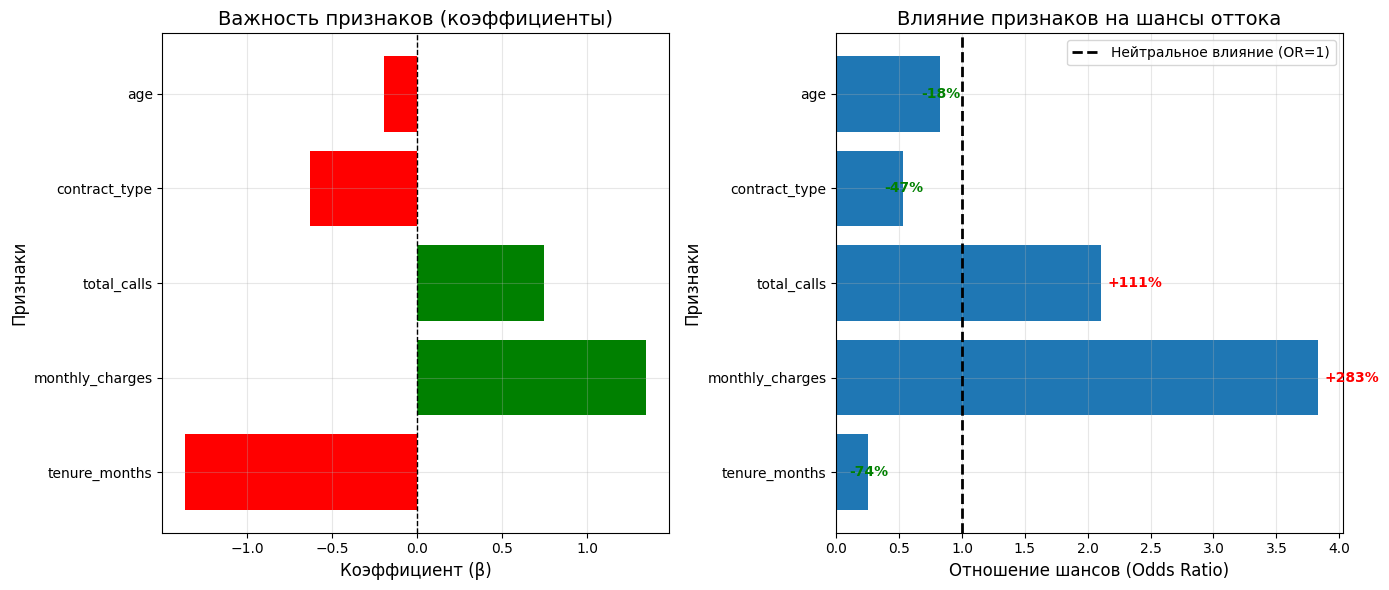

In [75]:
#Визуализация важности признаков
# Создаём визуализацию
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График коэффициентов
axes[0].barh(results_df['Признак'], results_df['Коэффициент (β)'],
             color=['red' if x < 0 else 'green' for x in results_df['Коэффициент (β)']])
axes[0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Коэффициент (β)', fontsize=12)
axes[0].set_ylabel('Признаки', fontsize=12)
axes[0].set_title('Важность признаков (коэффициенты)', fontsize=14)
axes[0].grid(True, alpha=0.3)

# График Odds Ratio
bars = axes[1].barh(results_df['Признак'], results_df['Отношение шансов (exp(β))'])
axes[1].axvline(x=1, color='black', linestyle='--', linewidth=2, label='Нейтральное влияние (OR=1)')
axes[1].set_xlabel('Отношение шансов (Odds Ratio)', fontsize=12)
axes[1].set_ylabel('Признаки', fontsize=12)
axes[1].set_title('Влияние признаков на шансы оттока', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Добавляем аннотации для OR
for i, (bar, odds) in enumerate(zip(bars, results_df['Отношение шансов (exp(β))'])):
    if odds > 1:
        axes[1].text(odds + 0.05, i, f'+{(odds-1)*100:.0f}%',
                    va='center', fontweight='bold', color='red')
    elif odds < 1:
        axes[1].text(odds - 0.15, i, f'-{(1-odds)*100:.0f}%',
                    va='center', fontweight='bold', color='green')

plt.tight_layout()
plt.show()

In [76]:
#Сравнение с истинными параметрами (для анализа)
print("СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ (для проверки)\n")


# Истинные коэффициенты из генерации данных
true_coefs = {
    'monthly_charges': 0.04,
    'tenure_months': -0.06,
    'total_calls': 0.25,
    'age': -0.01,
    'contract_type': -0.8
}

comparison_df = pd.DataFrame({
    'Признак': list(true_coefs.keys()),
    'Истинный β': [true_coefs[k] for k in list(true_coefs.keys())],
    'Найденный β': coefficients,
    'Разница': coefficients - [true_coefs[k] for k in list(true_coefs.keys())]
})
print(comparison_df.to_string(index=False, float_format='{:,.4f}'.format))

print("\nПримечание: Разница возникает из-за:")
print("1. Нелинейных эффектов в данных (взаимодействия, квадратичные члены)")
print("2. Шума (np.random.normal(0, 0.5))")
print("3. Логистическая регрессия моделирует только линейные зависимости")

СРАВНЕНИЕ С ИСТИННЫМИ ЗНАЧЕНИЯМИ (для проверки)

        Признак  Истинный β  Найденный β  Разница
monthly_charges      0.0400       1.3441   1.3041
  tenure_months     -0.0600      -1.3613  -1.3013
    total_calls      0.2500       0.7448   0.4948
            age     -0.0100      -0.1947  -0.1847
  contract_type     -0.8000      -0.6306   0.1694

Примечание: Разница возникает из-за:
1. Нелинейных эффектов в данных (взаимодействия, квадратичные члены)
2. Шума (np.random.normal(0, 0.5))
3. Логистическая регрессия моделирует только линейные зависимости


**Оценка качества**

Постройте матрицу ошибок (confusion matrix) для тестовой выборки.

Вычислите метрики: accuracy, precision, recall, F1-score.


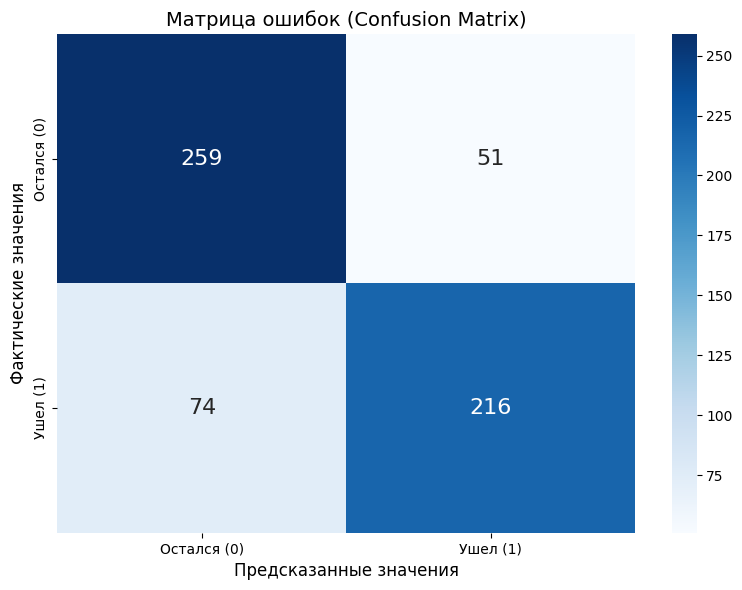


МАТРИЦА ОШИБОК:
True Negatives  (TN - Остался, предсказан как остался):       259
False Positives (FP - Остался, предсказан как ушел):          51
False Negatives (FN - Ушел, предсказан как остался):          74
True Positives  (TP - Ушел, предсказан как ушел):            216

МЕТРИКИ КАЧЕСТВА МОДЕЛИ:
Accuracy  (Точность):      0.7917  → 79.17% правильных предсказаний
Precision (Точность):      0.8090  → TP / (TP + FP) = 216 / (216 + 51) = 0.8090
Recall    (Полнота):       0.7448     → TP / (TP + FN) = 216 / (216 + 74) = 0.7448
F1-Score  (F1-мера):       0.7756         → 2 * (Precision * Recall) / (Precision + Recall)

ИНТЕРПРЕТАЦИЯ МЕТРИК:

📊 Accuracy (0.7917):
   Модель правильно предсказала 79.2% случаев

🎯 Precision (0.8090):
   ✅ Высокая точность - из всех предсказанных 'уходов' 80.9% верны

🔍 Recall (0.7448):
   ⚠ Средняя полнота - модель нашла 74.5% реально ушедших клиентов

⚖ F1-Score (0.7756):
   ⚠ Хороший баланс между точностью и полнотой

📈 Дополнительные метрики:
   Specif

In [77]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. ЗАГРУЗКА ДАННЫХ (из вашего файла)
df = pd.read_csv('logistic_data.csv')

# 2. ПОДГОТОВКА ДАННЫХ
X = df.drop('churn', axis=1)
y = df['churn']

# 3. РАЗДЕЛЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 4. СТАНДАРТИЗАЦИЯ
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. ОБУЧЕНИЕ МОДЕЛИ
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# 6. ПРЕДСКАЗАНИЯ
y_pred = model.predict(X_test_scaled)

# 7. ПОСТРОЕНИЕ МАТРИЦЫ ОШИБОК
cm = confusion_matrix(y_test, y_pred)

# Визуализация матрицы ошибок
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Остался (0)', 'Ушел (1)'],
            yticklabels=['Остался (0)', 'Ушел (1)'],
            annot_kws={'size': 16})
plt.xlabel('Предсказанные значения', fontsize=12)
plt.ylabel('Фактические значения', fontsize=12)
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=14)
plt.tight_layout()
plt.show()

# Вывод числовых значений матрицы ошибок
print("\n" + "="*50)
print("МАТРИЦА ОШИБОК:")
print("="*50)
print(f"True Negatives  (TN - Остался, предсказан как остался):     {cm[0,0]:5d}")
print(f"False Positives (FP - Остался, предсказан как ушел):       {cm[0,1]:5d}")
print(f"False Negatives (FN - Ушел, предсказан как остался):       {cm[1,0]:5d}")
print(f"True Positives  (TP - Ушел, предсказан как ушел):          {cm[1,1]:5d}")

# 8. ВЫЧИСЛЕНИЕ МЕТРИК
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*50)
print("МЕТРИКИ КАЧЕСТВА МОДЕЛИ:")
print("="*50)
print(f"Accuracy  (Точность):      {accuracy:.4f}  → {(accuracy*100):.2f}% правильных предсказаний")
print(f"Precision (Точность):      {precision:.4f}  → TP / (TP + FP) = {cm[1,1]} / ({cm[1,1]} + {cm[0,1]}) = {precision:.4f}")
print(f"Recall    (Полнота):       {recall:.4f}     → TP / (TP + FN) = {cm[1,1]} / ({cm[1,1]} + {cm[1,0]}) = {recall:.4f}")
print(f"F1-Score  (F1-мера):       {f1:.4f}         → 2 * (Precision * Recall) / (Precision + Recall)")

# 9. ПОДРОБНЫЙ АНАЛИЗ
print("\n" + "="*50)
print("ИНТЕРПРЕТАЦИЯ МЕТРИК:")
print("="*50)

print(f"\n📊 Accuracy ({accuracy:.4f}):")
print(f"   Модель правильно предсказала {(accuracy*100):.1f}% случаев")

print(f"\n🎯 Precision ({precision:.4f}):")
if precision > 0.8:
    print(f"   ✅ Высокая точность - из всех предсказанных 'уходов' {precision*100:.1f}% верны")
elif precision > 0.6:
    print(f"   ⚠ Средняя точность - из всех предсказанных 'уходов' {precision*100:.1f}% верны")
else:
    print(f"   ❌ Низкая точность - много ложных срабатываний")

print(f"\n🔍 Recall ({recall:.4f}):")
if recall > 0.8:
    print(f"   ✅ Высокая полнота - модель нашла {recall*100:.1f}% реально ушедших клиентов")
elif recall > 0.6:
    print(f"   ⚠ Средняя полнота - модель нашла {recall*100:.1f}% реально ушедших клиентов")
else:
    print(f"   ❌ Низкая полнота - модель пропустила {(1-recall)*100:.1f}% ушедших клиентов")

print(f"\n⚖ F1-Score ({f1:.4f}):")
if f1 > 0.8:
    print(f"   ✅ Отличный баланс между точностью и полнотой")
elif f1 > 0.6:
    print(f"   ⚠ Хороший баланс между точностью и полнотой")
else:
    print(f"   ❌ Плохой баланс - требуется улучшение модели")

# 10. ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ (для контекста)
specificity = cm[0,0] / (cm[0,0] + cm[0,1]) if (cm[0,0] + cm[0,1]) > 0 else 0
print(f"\n📈 Дополнительные метрики:")
print(f"   Specificity (Специфичность): {specificity:.4f}  → TN / (TN + FP)")
print(f"   False Positive Rate: {(1-specificity):.4f}")

# 11. СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ
baseline_accuracy = max(y_test.value_counts(normalize=True))
print(f"\n🏆 Сравнение с базовой моделью:")
print(f"   Baseline Accuracy (предсказание большинства): {baseline_accuracy:.4f}")
print(f"   Наша модель Accuracy: {accuracy:.4f}")
print(f"   Улучшение: {((accuracy - baseline_accuracy)/baseline_accuracy*100):.1f}%")